In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/cgpa_vs_package_cleaned.csv")

In [3]:
df.head()

,CGPA,Package
0,6.87,8.65
1,9.75,11.69
2,8.66,12.09
3,7.99,12.48
4,5.78,8.05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CGPA     5000 non-null   float64
 1   Package  5000 non-null   float64
dtypes: float64(2)
memory usage: 78.3 KB


In [5]:
X = df["CGPA"]
y = df["Package"]

In [6]:
X.head()

,CGPA
0,6.87
1,9.75
2,8.66
3,7.99
4,5.78


In [7]:
y.head()

,Package
0,8.65
1,11.69
2,12.09
3,12.48
4,8.05


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = X_train.values.reshape(-1,1)
X_test = X_test.values.reshape(-1,1)
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [10]:
X_train

array([[8.2 ],
       [5.24],
       [8.54],
       ...,
       [7.  ],
       [6.72],
       [8.88]])

In [11]:
X_test

array([[7.4 ],
       [5.36],
       [5.26],
       [6.75],
       [9.95],
       [7.05],
       [5.76],
       [7.38],
       [5.14],
       [5.96],
       [8.1 ],
       [9.46],
       [7.18],
       [5.09],
       [7.16],
       [6.71],
       [5.09],
       [7.12],
       [7.08],
       [9.72],
       [6.34],
       [6.32],
       [9.39],
       [6.06],
       [5.49],
       [7.68],
       [5.63],
       [5.58],
       [8.88],
       [5.23],
       [9.2 ],
       [8.88],
       [6.76],
       [6.78],
       [9.01],
       [9.63],
       [6.64],
       [5.89],
       [9.84],
       [6.98],
       [8.31],
       [7.63],
       [5.23],
       [7.71],
       [7.9 ],
       [7.57],
       [8.67],
       [9.76],
       [5.11],
       [8.29],
       [6.58],
       [8.23],
       [9.83],
       [8.94],
       [6.34],
       [5.77],
       [9.64],
       [5.2 ],
       [6.9 ],
       [7.03],
       [8.94],
       [9.21],
       [7.26],
       [6.87],
       [6.83],
       [5.83],
       [9.

In [12]:
y_train

array([[11.63],
       [ 7.26],
       [12.37],
       ...,
       [11.52],
       [10.65],
       [11.31]])

In [13]:
y_test

array([[ 9.66],
       [ 6.67],
       [ 8.06],
       [12.89],
       [14.87],
       [ 9.57],
       [ 8.5 ],
       [10.81],
       [ 5.97],
       [ 9.2 ],
       [11.49],
       [12.18],
       [11.06],
       [ 5.21],
       [ 9.48],
       [ 8.33],
       [ 5.55],
       [ 8.65],
       [11.25],
       [13.26],
       [ 8.59],
       [ 9.53],
       [13.39],
       [ 7.68],
       [ 5.83],
       [11.64],
       [ 6.76],
       [ 6.92],
       [12.57],
       [ 6.53],
       [12.49],
       [12.21],
       [ 7.73],
       [ 9.79],
       [12.32],
       [15.53],
       [ 8.47],
       [ 7.87],
       [15.38],
       [11.03],
       [11.91],
       [11.92],
       [ 5.1 ],
       [10.13],
       [11.56],
       [ 9.85],
       [13.4 ],
       [13.39],
       [ 5.84],
       [11.99],
       [11.43],
       [10.95],
       [13.9 ],
       [11.77],
       [ 8.38],
       [ 9.85],
       [15.64],
       [ 7.74],
       [10.67],
       [ 8.73],
       [12.97],
       [11.96],
       [

In [14]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
trained_model = lr.fit(X_train, y_train)

In [16]:
y_predict = trained_model.predict(X_test)

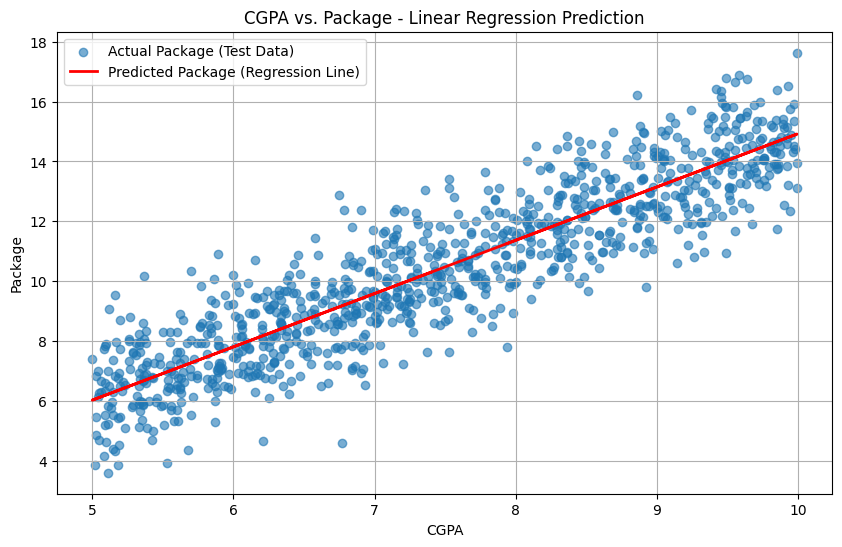

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Actual Package (Test Data)', alpha=0.6)
plt.plot(X_test, y_predict, color='red', linewidth=2, label='Predicted Package (Regression Line)')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('CGPA vs. Package - Linear Regression Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_predict)
print(f"R-squared score: {r2:.4f}")

R-squared score: 0.8107


In [19]:
def predict_package():
  """Takes X as input, predicts Package using the trained model, and prints the result."""
  while True:
    try:
      X_input = float(input("Enter X (e.g., 8.5): "))
      if not (0.0 <= X_input <= 10.0): # Assuming X is between 0 and 10
        print("X should be between 0.0 and 10.0. Please try again.")
        continue
      break
    except ValueError:
      print("Invalid input. Please enter a numerical value for X.")

  # Reshape the input for the model (single feature, single sample)
  X_for_prediction = np.array([[X_input]])

  # Make prediction using the trained model
  predicted_package = trained_model.predict(X_for_prediction)

  # The prediction is an array, so extract the scalar value
  print(f"For a X of {X_input}, the predicted package is: {predicted_package[0][0]:.2f}")

# You can call the function like this to test it:
# predict_package()

In [20]:
predict_package()

Enter X (e.g., 8.5): 11.2
X should be between 0.0 and 10.0. Please try again.
Enter X (e.g., 8.5): 8.2
For a X of 8.2, the predicted package is: 11.73
